Competition description

Twitter has become an important communication channel in times of emergency. The ubiquitousness of smartphones enables people to announce an emergency they’re observing in real-time. Because of this, more agencies are interested in programatically monitoring Twitter (i.e. disaster relief organizations and news agencies).

But, it’s not always clear whether a person’s words are actually announcing a disaster.

Acknowledgments

This dataset was created by the company figure-eight and originally shared on their ‘Data For Everyone’ website here.



Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import re
import string

Load csv files

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/nlp-getting-started/sample_submission.csv
/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/nlp-getting-started/test.csv


Read files

In [3]:
train  = pd.read_csv('/kaggle/input/nlp-getting-started/train.csv')
test = pd.read_csv('/kaggle/input/nlp-getting-started/test.csv')
submission = pd.read_csv('/kaggle/input/nlp-getting-started/sample_submission.csv')

In [4]:
train

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


In [5]:
test

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan
...,...,...,...,...
3258,10861,NaN,NaN,EARTHQUAKE SAFETY LOS ANGELES ÛÒ SAFETY FASTE...
3259,10865,NaN,NaN,Storm in RI worse than last hurricane. My city...
3260,10868,NaN,NaN,Green Line derailment in Chicago http://t.co/U...
3261,10874,NaN,NaN,MEG issues Hazardous Weather Outlook (HWO) htt...


In [6]:
submission

,id,target
0,0,0
1,2,0
2,3,0
3,9,0
4,11,0
...,...,...
3258,10861,0
3259,10865,0
3260,10868,0
3261,10874,0


Analyse train

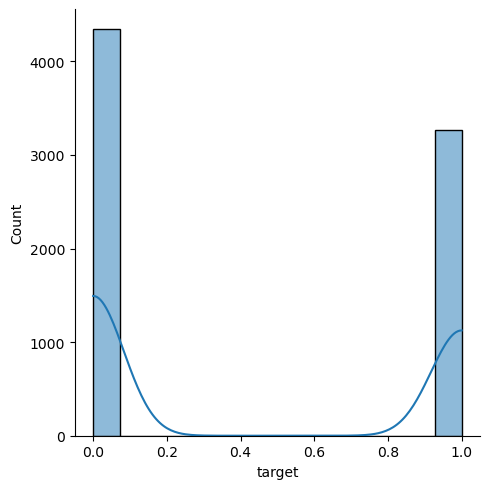

In [7]:
sns.displot(train['target'], kde=True)

In [8]:
train['target'].value_counts()

0    4342
1    3271
Name: target, dtype: int64

In [9]:
num_classes = train['target'].nunique()
print(num_classes)

2


Split dataset

In [10]:
X = train['text']
y = train['target']

X_test = test['text']

In [11]:
# Import functions from sklearn library
from sklearn.model_selection import train_test_split

# Splitting the data into training and testing sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1,random_state=42, shuffle=y)
X_train.shape, X_val.shape, y_train.shape, y_val.shape, X_test.shape

((6851,), (762,), (6851,), (762,), (3263,))

Tensorflow

In [12]:
import tensorflow as tf
print(tf.__version__)
import tensorflow_hub as hub
import tensorflow_text as text
from tensorflow import keras
from keras.callbacks import ModelCheckpoint, EarlyStopping

2.11.0


In [13]:
bert_preprocess = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3")
bert_encoder = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4")

In [14]:
#initialising bert layers
text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
preprocessed_text = bert_preprocess(text_input)
outputs = bert_encoder(preprocessed_text)

In [15]:
#initialising neural network layers
l = tf.keras.layers.Dropout(0.1, name="dropout")(outputs['pooled_output'])
l = tf.keras.layers.Dense(1, activation='sigmoid', name="output")(l)

In [16]:
#create model
model = tf.keras.Model(inputs=[text_input], outputs = [l])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 text (InputLayer)              [(None,)]            0           []                               
                                                                                                  
 keras_layer (KerasLayer)       {'input_mask': (Non  0           ['text[0][0]']                   
                                e, 128),                                                          
                                 'input_type_ids':                                                
                                (None, 128),                                                      
                                 'input_word_ids':                                                
                                (None, 128)}                                                  

In [17]:
#compile the model
METRICS = [
      tf.keras.metrics.BinaryAccuracy(name='accuracy'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall')
]

model.compile(optimizer='adam',
 loss='binary_crossentropy',
 metrics=METRICS)

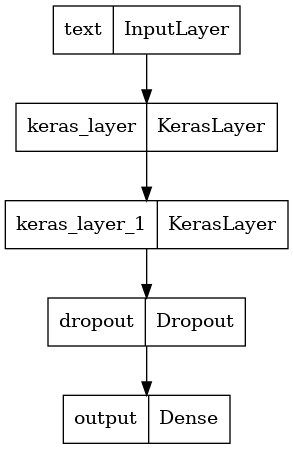

In [18]:
keras.utils.plot_model(model, "sentiment_classifier.png")

In [19]:
#fit the model
early_stopping = EarlyStopping(monitor='val_loss', mode='min', patience=25, verbose=1)
mc = ModelCheckpoint ('best_model.tf', monitor='val_loss', mode='min', save_best_only=True)

model.fit(X_train, y_train, epochs=15, validation_data=(X_val, y_val),verbose=1,callbacks=[early_stopping, mc])

Epoch 1/15
215/215 [==============================] - 79s 312ms/step - loss: 0.6176 - accuracy: 0.6628 - precision: 0.6292 - recall: 0.5186 - val_loss: 0.5920 - val_accuracy: 0.7244 - val_precision: 0.7266 - val_recall: 0.6012
Epoch 2/15
215/215 [==============================] - 65s 304ms/step - loss: 0.5808 - accuracy: 0.7030 - precision: 0.6733 - recall: 0.5956 - val_loss: 0.5704 - val_accuracy: 0.7415 - val_precision: 0.7264 - val_recall: 0.6637
Epoch 3/15
215/215 [==============================] - 65s 303ms/step - loss: 0.5736 - accuracy: 0.7139 - precision: 0.6882 - recall: 0.6075 - val_loss: 0.5609 - val_accuracy: 0.7428 - val_precision: 0.7652 - val_recall: 0.6012
Epoch 4/15
215/215 [==============================] - 65s 300ms/step - loss: 0.5573 - accuracy: 0.7270 - precision: 0.7063 - recall: 0.6211 - val_loss: 0.5496 - val_accuracy: 0.7533 - val_precision: 0.7761 - val_recall: 0.6190
Epoch 5/15
215/215 [==============================] - 66s 306ms/step - loss: 0.5511 - accura

In [20]:
results = model.evaluate(X_val, y_val, batch_size=128)

6/6 [==============================] - 7s 1s/step - loss: 0.5118 - accuracy: 0.7743 - precision: 0.8333 - recall: 0.6101


In [21]:
model.save('tweet_model')

In [22]:
#evaluate the model
predictions = model.predict(X_test)
predictions = predictions.flatten()
predictions

102/102 [==============================] - 23s 214ms/step


array([0.45007932, 0.38332865, 0.5764653 , ..., 0.77463245, 0.523532  ,
       0.6645585 ], dtype=float32)

In [23]:
cutoff = (predictions.max() - predictions.min()) / 2
predictions = np.where(predictions > 0.5, 1, 0)
predictions

array([0, 0, 1, ..., 1, 1, 1])

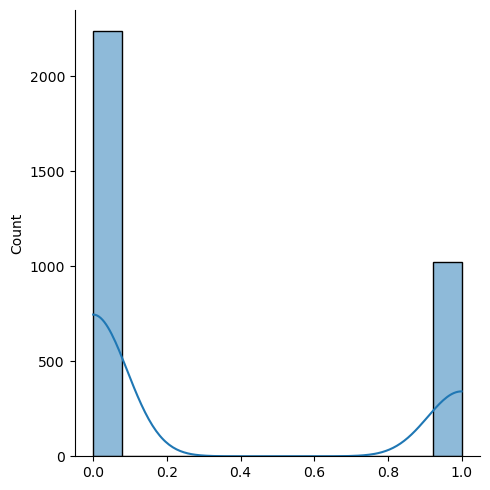

In [24]:
sns.displot(predictions, kde=True)

In [25]:
count_pred = np.unique(predictions, return_counts=True)
count_pred

(array([0, 1]), array([2238, 1025]))

Prepare submission

In [26]:

submission['target'] = predictions
submission.to_csv('submission.csv',index=False) # writing data to a CSV file
submission = pd.read_csv("submission.csv")
submission


,id,target
0,0,0
1,2,0
2,3,1
3,9,1
4,11,1
...,...,...
3258,10861,0
3259,10865,1
3260,10868,1
3261,10874,1
